In [1]:
import numpy as np
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler, StandardScaler

c:\Users\fpaul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.sparse import csr_matrix, issparse


# Questão 1

### Letra A

In [2]:
dataset = np.loadtxt("artificial1d.csv", delimiter=",", skiprows=1)

In [3]:
x = dataset[:, [0]]

y = dataset[:, [1]]

In [4]:
def remover_outliers(x, y, threshold=3):
    z_scores = np.abs((y - y.mean()) / y.std())
    mask = z_scores < threshold
    return x[mask], y[mask]

In [5]:
def plot(x, y, w1, w2, rmse1, rmse2):

    plt.scatter(x, y, label="Dados", alpha=0.6)

    # Linha original
    y_pred1 = w1[0] + w1[1] * x
    plt.plot(x, y_pred1, label=f"Com outliers (RMSE={rmse1:.2f})")

    # Linha sem outliers
    y_pred2 = w2[0] + w2[1] * x
    plt.plot(x, y_pred2, linestyle='--',
             label=f"Sem outliers (RMSE={rmse2:.2f})")

    plt.legend()
    plt.title("Comparação com e sem outliers")
    plt.show()

In [6]:
def regressao_linear(X_input, y):

    if X_input.ndim == 1:
        X_input = X_input.reshape(-1, 1)

    if y.ndim == 1:
        y = y.reshape(-1, 1)

    X = np.hstack((
        np.ones((X_input.shape[0], 1)),
        X_input
    ))

    w = np.linalg.inv(X.T @ X) @ X.T @ y

    y_hat = X @ w

    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

In [7]:
w1, rmse1 = regressao_linear(x, y)
x_clean, y_clean = remover_outliers(x, y)
w2, rmse2 = regressao_linear(x_clean, y_clean)

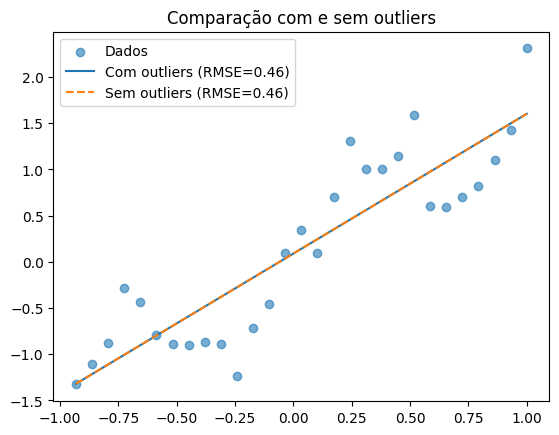

In [8]:
plot(x, y, w1, w2, rmse1, rmse2)

### Letra B

In [9]:
# Escreva o código aqui
def regressao_linear_gd(x, y, alpha, iteracoes):

    x_media = x.mean(axis=0, keepdims=True)
    x_std = x.std(axis=0)
    x_norm = (x - x_media) / x_std

    y_media = y.mean()
    y_std = y.std()
    y_norm = (y - y_media) / y_std

    X = np.hstack((np.ones((x_norm.shape[0], 1)), x_norm))

    N = X.shape[0]

    w = np.zeros((X.shape[1], 1))

    for _ in range(iteracoes):

        y_hat = X @ w
        erro = y_norm - y_hat

        gradiente = (X.T @ erro) / N

        w = w + alpha * gradiente

    y_pred_norm = X @ w

    y_pred = y_pred_norm * y_std + y_media

    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    return w, rmse

In [10]:
w1, rmse1 = regressao_linear_gd(x=x, y=y, alpha=0.01, iteracoes=1000)
x_clean, y_clean = remover_outliers(x, y)
w2, rmse2 = regressao_linear(x_clean, y_clean)

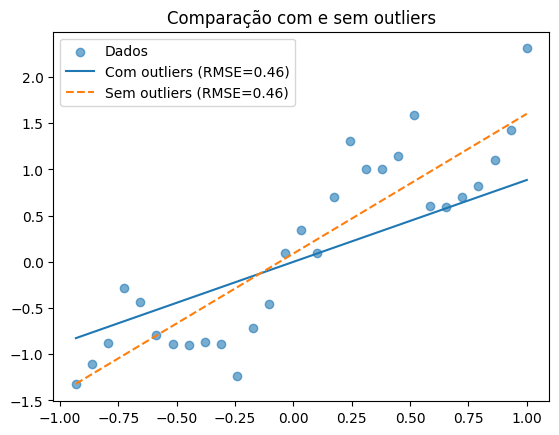

In [11]:
plot(x, y, w1, w2, rmse1, rmse2)

### Letra C

In [12]:
# Escreva o código aqui
def regressao_linear_sgd(x, y, alpha, epocas):

    x_media = x.mean(axis=0)
    x_std = x.std(axis=0)
    x_norm = (x - x_media) / x_std

    y_media = y.mean()
    y_std = y.std()
    y_norm = (y - y_media) / y_std

    X = np.hstack((np.ones((x_norm.shape[0], 1)), x_norm))

    N = X.shape[0]

    w = np.zeros((X.shape[1], 1))

    for _ in range(epocas):
        for i in range(N):

            xi = X[i].reshape(-1,1)
            yi = y_norm[i]

            y_hat = w.T @ xi
            erro = yi - y_hat

            w = w + alpha * erro * xi

    y_pred_norm = X @ w

    y_pred = y_pred_norm * y_std + y_media

    rmse = np.sqrt(np.mean((y - y_pred) ** 2))

    return w, rmse

In [13]:
w1, rmse1 = regressao_linear_sgd(x=x, y=y, alpha=0.01, epocas=100)
x_clean, y_clean = remover_outliers(x, y)
w2, rmse2 = regressao_linear(x_clean, y_clean)

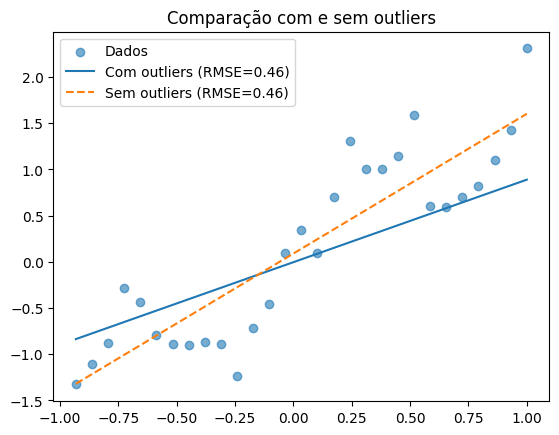

In [14]:
plot(x, y, w1, w2, rmse1, rmse2)

# Questão 2

In [15]:
california = np.loadtxt("california.csv", delimiter=",", skiprows=1)
X = california[:, :8] 
y = california[:, 8]  

### Letra A

In [16]:
def separa_dados(X, y, treino=0.8):
    n = X.shape[0]

    indices = np.random.permutation(n)

    split = int(n * treino)

    train_idx = indices[:split]
    test_idx = indices[split:]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [17]:
X_train, X_test, y_train, y_test = separa_dados(X, y, treino=0.8)

### Letra B

In [18]:
def regressao_polinomial(x, y, grau):

    X = np.ones((x.shape[0], 1))

    for i in range(1, grau + 1):
        X = np.hstack((X, x**i))

    w = np.linalg.inv(X.T @ X) @ X.T @ y

    y_hat = X @ w

    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

In [19]:
graus = []
rmse_treino = []
rmse_teste = []

In [20]:
for grau in range(1, 14):
    w, rmse_train = regressao_polinomial(X_train, y_train, grau)

    X_test_poly = np.ones((X_test.shape[0], 1))
    for i in range(1, grau + 1):
        X_test_poly = np.hstack((X_test_poly, X_test**i))

    y_pred_test = X_test_poly @ w
    rmse_test = np.sqrt(np.mean((y_test - y_pred_test)**2))

    graus.append(grau)
    rmse_treino.append(rmse_train)
    rmse_teste.append(rmse_test)

    print(f"Grau {grau} -> RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")

Grau 1 -> RMSE treino: 0.6798 | RMSE teste: 0.6346
Grau 2 -> RMSE treino: 0.6573 | RMSE teste: 0.6125
Grau 3 -> RMSE treino: 0.6331 | RMSE teste: 0.5951
Grau 4 -> RMSE treino: 0.8186 | RMSE teste: 0.8028
Grau 5 -> RMSE treino: 0.9323 | RMSE teste: 0.9295
Grau 6 -> RMSE treino: 10.0049 | RMSE teste: 7.5114
Grau 7 -> RMSE treino: 1.7017 | RMSE teste: 1.2531
Grau 8 -> RMSE treino: 32.9159 | RMSE teste: 28.9967
Grau 9 -> RMSE treino: 14.7335 | RMSE teste: 15.8625
Grau 10 -> RMSE treino: 24.7944 | RMSE teste: 51.2573
Grau 11 -> RMSE treino: 136.8439 | RMSE teste: 1050.0461
Grau 12 -> RMSE treino: 288.5480 | RMSE teste: 2217.7401
Grau 13 -> RMSE treino: 4185.5298 | RMSE teste: 45446.2753


### Letra C

In [21]:
def plot_2(graus, titulo, rmse):
    plt.figure()
    plt.plot(graus, rmse, marker='o')
    plt.title(titulo)
    plt.xlabel("Grau do Polinômio")
    plt.ylabel("RMSE")
    plt.grid()
    plt.show()

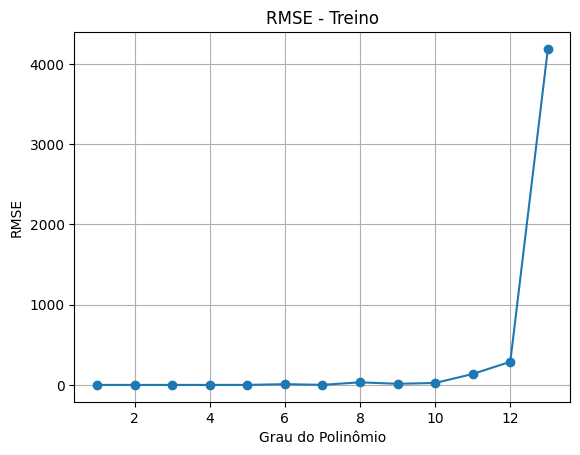

In [22]:
plot_2(graus=graus, titulo="RMSE - Treino", rmse=rmse_treino)

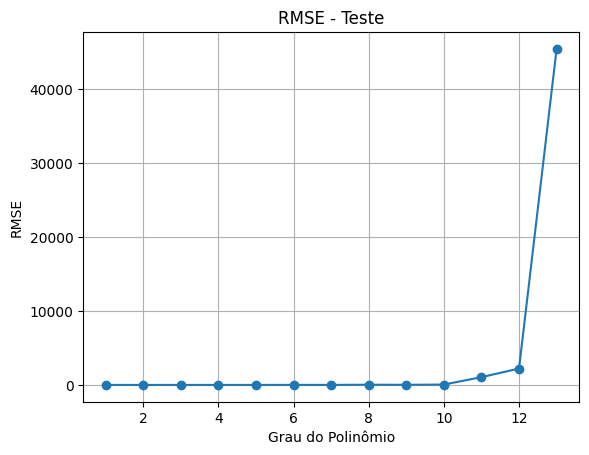

In [23]:
plot_2(graus=graus, titulo="RMSE - Teste", rmse=rmse_teste)

### Letra D

In [24]:
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm = scaler_X.transform(X_test)

y_train_norm = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_norm = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [25]:
def cria_matriz_polinomial(X, grau):
    X_poly = np.ones((X.shape[0], 1))
    
    for i in range(1, grau + 1):
        X_poly = np.hstack((X_poly, X**i))
    
    return X_poly

In [26]:
def regressao_polinomial_l2(X, y, grau, lamb=0.01):
    X_poly = cria_matriz_polinomial(X, grau)

    n_features = X_poly.shape[1]
    I = np.eye(n_features)

    I[0, 0] = 0

    w = np.linalg.inv(X_poly.T @ X_poly + lamb * I) @ X_poly.T @ y

    y_hat = X_poly @ w
    rmse = np.sqrt(np.mean((y - y_hat)**2))

    return w, rmse

In [27]:
graus = []
rmse_treino_l2 = []
rmse_teste_l2 = []

In [28]:
for grau in range(1, 14):
    w, rmse_train = regressao_polinomial_l2(X_train_norm, y_train_norm, grau, lamb=0.01)

    X_test_poly = cria_matriz_polinomial(X_test_norm, grau)
    y_pred_test_norm = X_test_poly @ w

    y_pred_test = scaler_y.inverse_transform(y_pred_test_norm.reshape(-1, 1)).ravel()
    y_test_real = scaler_y.inverse_transform(y_test_norm.reshape(-1, 1)).ravel()

    rmse_test = np.sqrt(np.mean((y_test_real - y_pred_test)**2))

    graus.append(grau)
    rmse_treino_l2.append(rmse_train)
    rmse_teste_l2.append(rmse_test)

    print(f"[L2] Grau {grau} -> RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")

[L2] Grau 1 -> RMSE treino: 0.5964 | RMSE teste: 0.6349
[L2] Grau 2 -> RMSE treino: 0.5769 | RMSE teste: 0.6138
[L2] Grau 3 -> RMSE treino: 0.5622 | RMSE teste: 0.6023
[L2] Grau 4 -> RMSE treino: 0.5600 | RMSE teste: 0.5983
[L2] Grau 5 -> RMSE treino: 0.5589 | RMSE teste: 0.5972
[L2] Grau 6 -> RMSE treino: 0.5583 | RMSE teste: 0.5970
[L2] Grau 7 -> RMSE treino: 0.5577 | RMSE teste: 0.5968
[L2] Grau 8 -> RMSE treino: 0.5568 | RMSE teste: 0.5962
[L2] Grau 9 -> RMSE treino: 0.5556 | RMSE teste: 0.5958
[L2] Grau 10 -> RMSE treino: 0.5544 | RMSE teste: 0.5958
[L2] Grau 11 -> RMSE treino: 0.5534 | RMSE teste: 0.5963
[L2] Grau 12 -> RMSE treino: 0.5526 | RMSE teste: 0.5972
[L2] Grau 13 -> RMSE treino: 0.5521 | RMSE teste: 0.5984


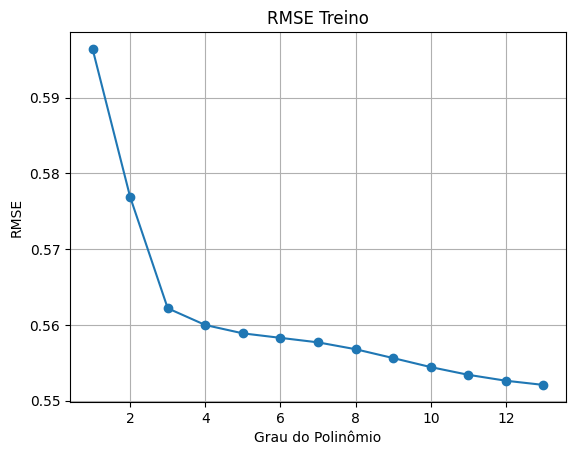

In [29]:
plot_2(graus, "RMSE Treino", rmse_treino_l2)

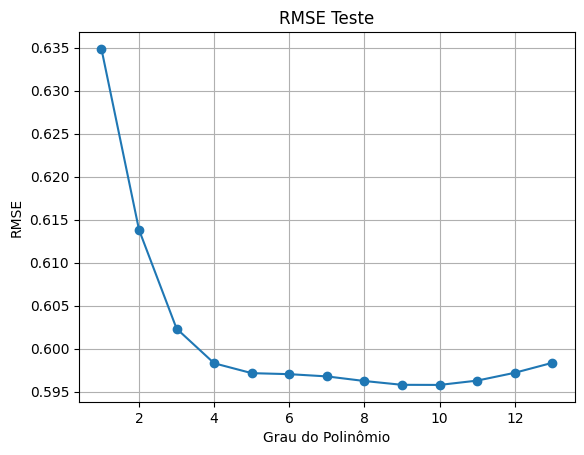

In [30]:
plot_2(graus, "RMSE Teste", rmse_teste_l2)